# 2.11 Ingénierie des caractéristiques

## 1. Introduction
L'ingénierie des caractéristiques (*feature engineering*) est le processus qui transforme des données brutes en grandeurs — les caractéristiques (*features*) — utilisables pour l'analyse statistique et la prédiction.

Les grands types de caractéristiques :

### Caractéristiques statistiques

Les caractéristiques statistiques résument la distribution des valeurs : tendance centrale, dispersion et forme.

* **Moyenne** : valeur moyenne des points de données.
* **Variance / écart-type** : mesure de l'étalement des données.
* **Asymétrie (*skewness*)** : asymétrie de la distribution des valeurs.
* **Kurtosis** : « épaisseur des queues » de la distribution.
* **Centiles** : valeurs seuils délimitant différents segments de la distribution.

### Caractéristiques temporelles
Les caractéristiques temporelles décrivent les motifs qui dépendent du temps au sein d'une série.

* **Autocorrélation** : corrélation d'une série temporelle avec une version décalée d'elle-même.
* **Tendance** : augmentation ou diminution de long terme dans les données.
* **Saisonnalité** : motifs réguliers qui se répètent sur une période donnée.
* **Points de rupture** : endroits où les propriétés statistiques de la série changent.

Ci-dessous, nous construisons une série journalière synthétique avec une tendance et un cycle annuel, nous en retirons la tendance et nous mesurons l'autocorrélation à décalage 1 de ce qui reste.

🖥️ [**Diapositives du cours — Séance 09 (lun. 19 oct.)**](https://geo-smart.github.io/mlgeo-book/slides/2026/lec09_synthetic_truth.html)

Lag-1 autocorrelation of the detrended seasonal series: 0.68


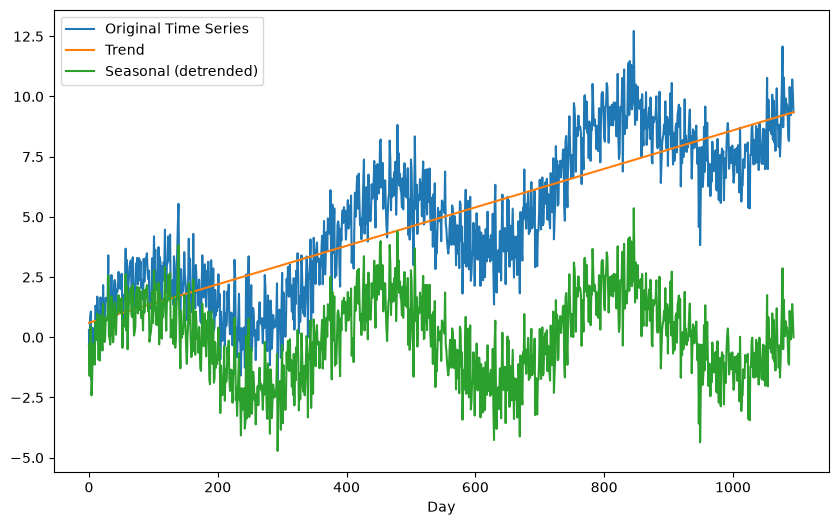

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Create a 3-year daily time series with trend and seasonality
t = np.arange(0, 365 * 3)
seasonal_series = rng.standard_normal(3 * 365) + np.linspace(0, 10, 3 * 365) + \
    2 * np.sin(2 * np.pi * np.linspace(0, 3, 3 * 365))

# fit a trend using least squares regression
slope, intercept = np.polyfit(t, seasonal_series, 1)
trend = slope * t + intercept
# the seasonal component is what remains after removing the trend
seasonal = seasonal_series - trend
# lag-1 autocorrelation of the detrended series
autocorr_seasonal = np.corrcoef(seasonal[:-1], seasonal[1:])[0, 1]
print(f'Lag-1 autocorrelation of the detrended seasonal series: {autocorr_seasonal:.2f}')

# Plot the original time series, trend, and seasonal component
plt.figure(figsize=(10, 6))
plt.plot(seasonal_series, label='Original Time Series')
plt.plot(trend, label='Trend')
plt.plot(seasonal, label='Seasonal (detrended)')
plt.xlabel('Day')
plt.legend()

La série détendancée porte toujours le cycle annuel : des jours voisins se ressemblent donc, et l'autocorrélation à décalage 1 est élevée. Comparez avec un bruit blanc pur de même longueur : le bruit blanc n'a pas de mémoire, donc son autocorrélation à décalage 1 est proche de zéro.

In [2]:
white_series = rng.standard_normal(3 * 365)

autocorr_white = np.corrcoef(white_series[:-1], white_series[1:])[0, 1]
print(f'Lag-1 autocorrelation of the detrended seasonal series: {autocorr_seasonal:.2f}')
print(f'Lag-1 autocorrelation of white noise:                   {autocorr_white:.2f}')

Lag-1 autocorrelation of the detrended seasonal series: 0.68
Lag-1 autocorrelation of white noise:                   -0.00


### Caractéristiques spatiales

Pour les données géospatiales, les caractéristiques spatiales capturent les relations entre différents lieux d'une image ou d'un jeu de données.

* **Texture** : motifs des variations locales d'intensité (lisse, rugueux, par exemple).
* **Corrélation spatiale** : mesure à quel point des lieux voisins se ressemblent en valeurs d'intensité.

Text(0.5, 1.0, '2D Spatially Correlated Noise')

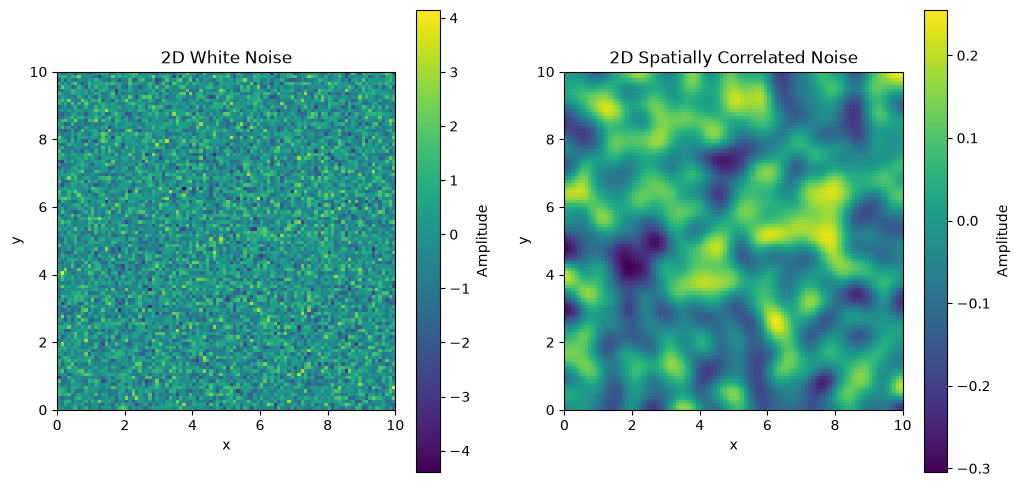

In [3]:
from scipy.ndimage import gaussian_filter
from scipy.fft import fft2, ifft2, fftshift

# Generate a 2D grid (e.g., geospatial data, such as a topographic map)
n = 100  # size of the grid
x = np.linspace(0, 10, n)
y = np.linspace(0, 10, n)
X2d, Y2d = np.meshgrid(x, y)

# 2D white noise
white_noise_2d = rng.standard_normal((n, n))

# Spatially correlated noise: smooth the white noise with a Gaussian filter
spatially_correlated_noise = gaussian_filter(white_noise_2d, sigma=3)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(white_noise_2d, extent=[0, 10, 0, 10], cmap='viridis')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='Amplitude')
plt.title('2D White Noise')

plt.subplot(1, 2, 2)
plt.imshow(spatially_correlated_noise, extent=[0, 10, 0, 10], cmap='viridis')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='Amplitude')
plt.title('2D Spatially Correlated Noise')

Autocorrélation spatiale du bruit blanc, calculée via le spectre de puissance (théorème de Wiener-Khintchine) :

In [4]:
# 2D Fourier transform of the white noise
fft_white_noise = fft2(white_noise_2d)

# power spectrum
power_spectrum = np.abs(fft_white_noise) ** 2

# inverse transform of the power spectrum gives the autocorrelation function
autocorrelation_white = np.real(ifft2(power_spectrum))

# shift the zero-lag component to the center
autocorrelation_white = fftshift(autocorrelation_white)

# normalize
autocorrelation_white /= autocorrelation_white.max()

Autocorrélation spatiale du bruit corrélé :

In [5]:
fft_noise = fft2(spatially_correlated_noise)
power_spectrum = np.abs(fft_noise) ** 2
autocorrelation = np.real(ifft2(power_spectrum))
autocorrelation = fftshift(autocorrelation)
autocorrelation /= autocorrelation.max()

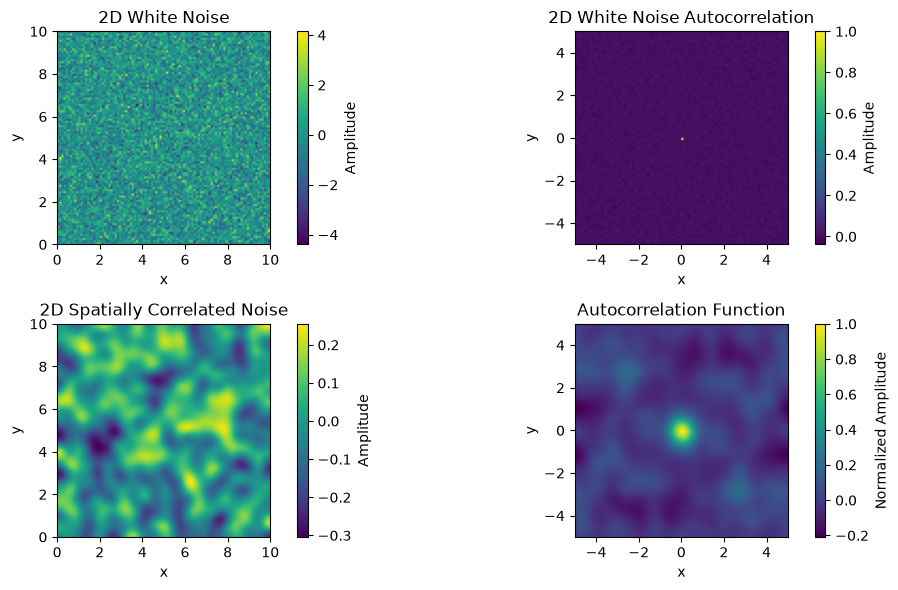

In [6]:
plt.figure(figsize=(11, 6))

# White noise (unfiltered)
plt.subplot(2, 2, 1)
plt.imshow(white_noise_2d, extent=[0, 10, 0, 10], cmap='viridis')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='Amplitude')
plt.title('2D White Noise')

plt.subplot(2, 2, 2)
plt.imshow(autocorrelation_white, extent=[-5, 5, -5, 5], cmap='viridis')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='Amplitude')
plt.title('2D White Noise Autocorrelation')

# Spatially correlated noise
plt.subplot(2, 2, 3)
plt.imshow(spatially_correlated_noise, extent=[0, 10, 0, 10], cmap='viridis')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='Amplitude')
plt.title('2D Spatially Correlated Noise')

plt.subplot(2, 2, 4)
plt.imshow(autocorrelation, extent=[-5, 5, -5, 5], cmap='viridis')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='Normalized Amplitude')
plt.title('Autocorrelation Function')

plt.tight_layout()
plt.show()

Estimez la caractéristique « longueur de corrélation » des deux images. La longueur de corrélation se mesure souvent comme la distance à laquelle la fonction d'autocorrélation décroît à 1/e de sa valeur maximale.

In [7]:
center = n // 2
# correlation length for the white noise
autocorr_center = autocorrelation_white[center, center:]
distances = np.linspace(0, 5, center)
correlation_length_white = np.interp(1 / np.e, autocorr_center[::-1], distances[::-1])

# correlation length for the spatially correlated noise
autocorr_center = autocorrelation[center, center:]
correlation_length = np.interp(1 / np.e, autocorr_center[::-1], distances[::-1])

print(f'Estimated correlation length for white noise: {correlation_length_white:.2f} '
      f'and for spatially correlated noise: {correlation_length:.2f}')

Estimated correlation length for white noise: 0.07 and for spatially correlated noise: 0.61


### Caractéristiques fractales
Les caractéristiques fractales décrivent l'auto-similarité ou la complexité des données à travers les échelles. La plus courante est la **dimension fractale** : une courbe lisse a une dimension proche de 1, tandis qu'une courbe rugueuse, qui remplit davantage le plan, a une dimension plus proche de 2.

La méthode de Higuchi estime la dimension fractale d'une série temporelle. Elle mesure la « longueur » moyenne de la courbe à des sous-échantillonnages de plus en plus grossiers ; la pente de log(longueur) en fonction de log(échelle) donne la dimension.

In [8]:
def higuchi_fd(series, kmax=10):
    """Higuchi fractal dimension of a 1D time series.

    Builds kmax coarse-grained versions of the series, measures the mean
    curve length at each scale k, and fits the slope of
    log(length) vs log(1/k). Returns the estimated fractal dimension,
    between 1 (smooth) and 2 (rough).
    """
    series = np.asarray(series, dtype=float)
    npts = len(series)
    lengths = []
    for k in range(1, kmax + 1):
        lk = []
        for m in range(k):
            idx = np.arange(m, npts, k)
            if len(idx) < 2:
                continue
            dist = np.sum(np.abs(np.diff(series[idx])))
            # normalization factor for the subsampled curve
            norm = (npts - 1) / (len(idx) - 1) / k
            lk.append(dist * norm / k)
        lengths.append(np.mean(lk))
    coeffs = np.polyfit(np.log(1.0 / np.arange(1, kmax + 1)), np.log(lengths), 1)
    return coeffs[0]


print(f'Higuchi fractal dimension of white noise:         '
      f'{higuchi_fd(white_series):.2f}')
print(f'Higuchi fractal dimension of the seasonal series: '
      f'{higuchi_fd(seasonal_series):.2f}')
smooth_series = gaussian_filter(white_series, sigma=5)
print(f'Higuchi fractal dimension of smoothed noise:      '
      f'{higuchi_fd(smooth_series):.2f}')

Higuchi fractal dimension of white noise:         1.99
Higuchi fractal dimension of the seasonal series: 1.98
Higuchi fractal dimension of smoothed noise:      1.10


Le bruit blanc est maximalement rugueux : sa dimension est donc proche de 2. Le lissage abaisse la dimension vers 1. La dimension fractale est un nombre unique qui résume la rugosité, ce qui en fait une caractéristique compacte pour classer des signaux.

## 2. Exemple sur des séries temporelles sismiques
Cette section montre comment extraire automatiquement des caractéristiques avec un simple paquet Python, `tsfel`, appliqué à des formes d'onde sismiques enregistrées dans le Nord-Ouest Pacifique.

Le sous-ensemble miniPNW contient des formes d'onde sismiques étiquetées pour des événements d'origines variées :

- **Séismes**
- **Explosions** (surtout des tirs de carrière)
- **Événements de surface** (avalanches et glissements de terrain, par exemple)
- **Bangs soniques**
- **Tonnerre**

Nous allons explorer comment les caractéristiques varient d'une classe d'événements sismiques à l'autre.

**Citation du jeu de données.** Les données sont un sous-ensemble du jeu de données de référence PNW-ML : Ni, Y., Hutko, A., Skene, F., Denolle, M., Malone, S., Bodin, P., Hartog, R., & Wright, A. (2023). Curated Pacific Northwest AI-ready Seismic Dataset. *Seismica*, 2(1). doi:[10.26443/seismica.v2i1.368](https://doi.org/10.26443/seismica.v2i1.368). Le chemin d'accès archivé au jeu de données complet est `seisbench.data.PNW()` ; nous utilisons ici un petit sous-ensemble (« miniPNW ») hébergé sur un serveur de la classe.

In [9]:
# Import modules for seismic data and feature extraction
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import scipy.stats as st
import os
import urllib.request
import h5py  # for reading .h5 files

Nous téléchargeons deux fichiers depuis le stockage de la classe vers `./data/` : les formes d'onde dans un fichier HDF5 et leurs métadonnées associées dans un fichier CSV. Le fichier de métadonnées est petit. Le fichier de formes d'onde est volumineux (environ 1 Go), nous protégeons donc son téléchargement : en cas d'échec, le carnet affiche un message et saute les cellules qui dépendent des formes d'onde.

In [10]:
os.makedirs('data', exist_ok=True)

base_url = 'https://dasway.ess.washington.edu/shared/niyiyu/PNW-ML'
metadata_path = './data/miniPNW_metadata.csv'
waveform_path = './data/miniPNW_waveforms.hdf5'

# metadata: small CSV, always download if missing
if not os.path.exists(metadata_path):
    urllib.request.urlretrieve(f'{base_url}/miniPNW_metadata.csv', metadata_path)
print(f'Metadata file present: {os.path.exists(metadata_path)}')

# waveforms: large HDF5, guarded download
if not os.path.exists(waveform_path):
    try:
        print('Downloading waveform file (large, be patient)...')
        urllib.request.urlretrieve(f'{base_url}/miniPNW_waveforms.hdf5',
                                   waveform_path)
    except Exception as e:
        if os.path.exists(waveform_path):
            os.remove(waveform_path)  # remove partial file
        raise RuntimeError(
            'Could not download miniPNW_waveforms.hdf5 from '
            f'{base_url}. Check your network connection, or place the file '
            'manually in ./data/. Original error: ' + repr(e)) from e
print(f'Waveform file present: {os.path.exists(waveform_path)}')

Metadata file present: True
Waveform file present: True


## Métadonnées

Nous lisons d'abord les métadonnées et les organisons dans une table de données (*data frame*) pandas, un objet `DataFrame`.

In [11]:
df = pd.read_csv(metadata_path)
# Display the first few rows of the DataFrame
df.head()

,Unnamed: 0,event_id,source_origin_time,source_latitude_deg,source_longitude_deg,source_type,source_depth_km,preferred_source_magnitude,preferred_source_magnitude_type,preferred_source_magnitude_uncertainty,...,trace_S_onset,trace_P_onset,trace_snr_db,year,source_type_pnsn_label,source_local_magnitude,source_local_magnitude_uncertainty,source_duration_magnitude,source_duration_magnitude_uncertainty,source_hand_magnitude
0,0,uw61669232,2020-09-07T03:44:14.690000Z,46.560,-119.797,earthquake,23.300,1.30,ml,0.241,...,impulsive,impulsive,-1.444|2.612|9.921,2020.0,eq,1.30,0.241,1.17,0.188,NaN
1,1,uw60888282,2014-10-08T15:39:31.330000Z,45.371,-121.708,earthquake,-0.947,1.67,ml,0.128,...,impulsive,impulsive,0.368|3.526|5.981,2014.0,eq,1.67,0.128,1.63,0.099,NaN
2,2,uw61361706,2017-12-30T04:37:46.870000Z,46.165,-120.543,earthquake,13.520,2.46,ml,0.158,...,impulsive,emergent,11.274|13.32|15.828,2017.0,eq,2.46,0.158,3.37,0.389,NaN
3,3,uw61639436,2020-06-09T23:37:10.420000Z,46.542,-119.589,earthquake,16.370,1.59,ml,0.157,...,impulsive,emergent,27.007|20.797|19.252,2020.0,eq,1.59,0.157,1.69,0.355,NaN
4,4,uw61735446,2021-05-24T10:42:37.810000Z,46.857,-121.941,earthquake,12.380,0.83,ml,0.083,...,impulsive,emergent,18.579|18.912|7.609,2021.0,eq,0.83,0.083,0.50,0.382,NaN


La nature de la source de l'événement est stockée dans l'un des attributs de métadonnées.

In [12]:
df['source_type'].unique()

<ArrowStringArray>
['earthquake', 'explosion', 'sonic_boom', 'thunder', 'surface_event']
Length: 5, dtype: str

Supposons que nous explorions des caractéristiques pour classer les formes d'onde selon les catégories de types d'événements. Nous prenons l'attribut ``source_type`` comme **étiquette**.

In [13]:
labels = df['source_type']
print(labels.value_counts())

source_type
earthquake       500
explosion        500
surface_event    500
sonic_boom       126
thunder           94
Name: count, dtype: int64


Combien y a-t-il de formes d'onde sismiques dans chaque catégorie ?

In [14]:
counts = labels.value_counts()
fractions = counts / counts.sum()
for name, count in counts.items():
    print(f'{name:>15s}: {count:5d} waveforms ({100 * fractions[name]:.1f}%)')

     earthquake:   500 waveforms (29.1%)
      explosion:   500 waveforms (29.1%)
  surface_event:   500 waveforms (29.1%)
     sonic_boom:   126 waveforms (7.3%)
        thunder:    94 waveforms (5.5%)


Diriez-vous que ce jeu de données est équilibré vis-à-vis des classes qui nous intéressent ? Le déséquilibre des classes compte : un classifieur entraîné sur cet ensemble verra bien plus souvent la classe dominante, et l'exactitude seule devient un score trompeur.

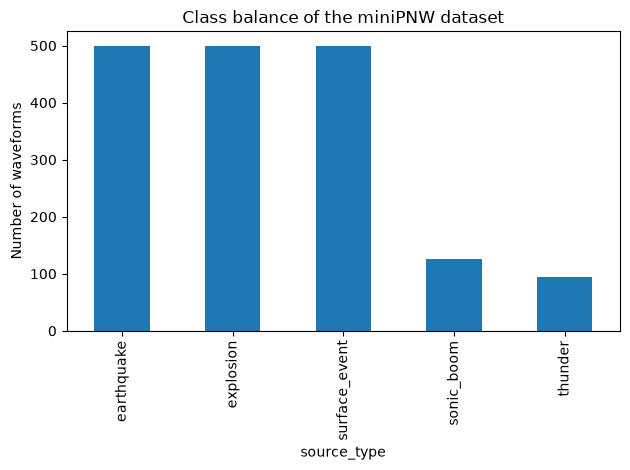

In [15]:
counts.plot(kind='bar')
plt.ylabel('Number of waveforms')
plt.title('Class balance of the miniPNW dataset')
plt.tight_layout()

## Données de formes d'onde

Nous lisons maintenant les données de formes d'onde. Elles sont stockées dans un fichier HDF5, réparties sur un nombre fini de groupes. Chaque groupe contient un tableau (*array*) de jeux de données correspondant aux formes d'onde. Pour relier les métadonnées aux fichiers de formes d'onde, la clé ``trace_name`` porte l'identifiant du jeu de données. L'adresse est étiquetée ainsi :
```
bucketX$i,:3,:n
```

où ``X`` est le numéro du groupe HDF5 et ``i`` l'indice. Le fichier contient typiquement 3 formes d'onde, une par direction du mouvement du sol : N, E, Z. Dans ce qui suit, nous nous concentrons sur les formes d'onde verticales (Z).

Toutes les cellules qui ont besoin du fichier de formes d'onde sont conditionnées par un test d'existence du fichier, de sorte que le carnet s'exécute encore de bout en bout si le téléchargement a échoué.

In [16]:
chan_list = ['N', 'E', 'Z']

if os.path.exists(waveform_path):
    f = h5py.File(waveform_path, 'r')
else:
    print('Waveform file not found: skipping waveform cells.')

Ci-dessous, une fonction pour lire une forme d'onde dans le fichier.

In [17]:
def read_data(tn, f):
    """
    Read the waveform data from the .h5 file.
    tn: trace_name of the waveform
    f: open h5py file object
    """
    bucket, narray = tn.split('$')  # split trace_name into bucket and indices
    x, y, z = [int(i) for i in narray.split(',:')]
    data = f['/data/%s' % bucket][x, :y, :z]  # read the data as a 2D array
    return data

Le nom de la trace est stocké comme attribut de données dans les métadonnées.

In [18]:
trace_names = list(df['trace_name'])
trace_names[0]

'bucket1$0,:3,:15001'

The first dimension of the data is 3
The second dimension of the data is 15001


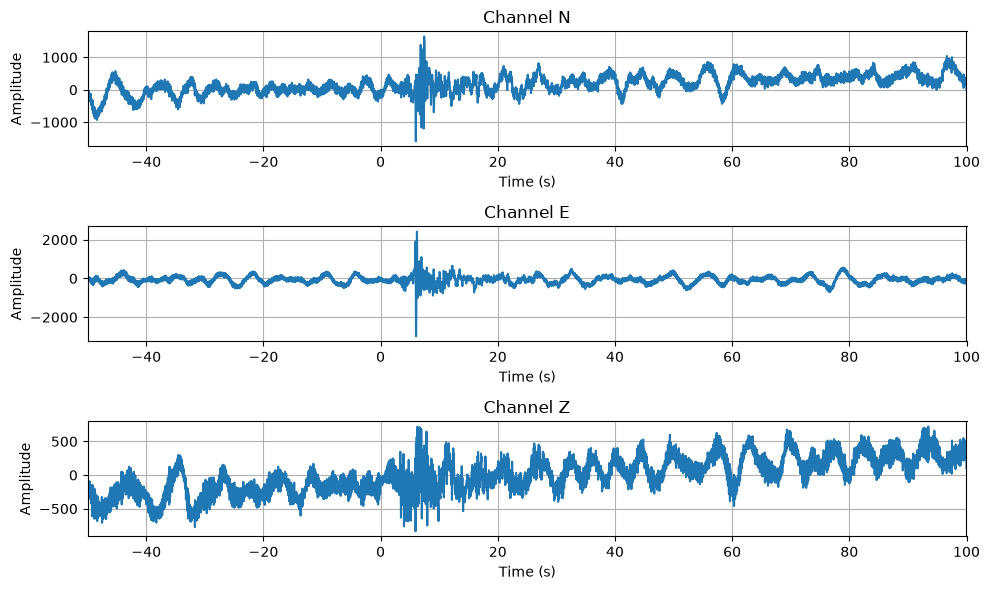

In [19]:
if os.path.exists(waveform_path):
    example_waveform = read_data(trace_names[530], f)
    print(f'The first dimension of the data is {example_waveform.shape[0]}')
    print(f'The second dimension of the data is {example_waveform.shape[1]}')

    # the time vector goes from -50 to 100 s around the pick, at 100 Hz
    t = np.linspace(-50, 100, example_waveform.shape[1])

    # plot an example of the data in a 3-row subplot
    fig, ax = plt.subplots(3, 1, figsize=(10, 6))
    for i in range(3):
        ax[i].plot(t, example_waveform[i, :])
        ax[i].set_title(f'Channel {chan_list[i]}')
        ax[i].set_xlabel('Time (s)')
        ax[i].set_ylabel('Amplitude')
        ax[i].grid(True)
        ax[i].set_xlim(-50, 100)
    plt.tight_layout()
else:
    print('Waveform file not found: skipping waveform plot.')

Nous extrayons la composante Z de chaque forme d'onde et les empilons dans un seul tableau.

In [20]:
if os.path.exists(waveform_path):
    nt = example_waveform.shape[-1]
    ndata = len(labels)
    Z = np.zeros(shape=(ndata, nt))
    for i in range(ndata):
        Z[i, :] = read_data(df.iloc[i]['trace_name'], f)[2, :nt]
    print(f'We have a total of {Z.shape[0]} data samples and each has '
          f'{Z.shape[1]} data points')
else:
    print('Waveform file not found: skipping waveform stacking.')

We have a total of 1720 data samples and each has 15001 data points


## Extraction automatique de caractéristiques avec tsfel

Nous disposons maintenant des données et de leurs attributs, en particulier l'étiquette qu'est le type de source. Nous allons extraire des caractéristiques automatiquement avec `tsfel` et explorer comment elles varient d'une classe à l'autre.

`tsfel` organise les caractéristiques par domaine (statistique, temporel, spectral). Nous chargeons la configuration par défaut :

In [21]:
import tsfel

cfg = tsfel.get_features_by_domain()
print(list(cfg.keys()))

['spectral', 'statistical', 'temporal', 'fractal']


`tsfel` prend un tableau 1D et la fréquence d'échantillonnage, et renvoie un `DataFrame` d'une seule ligne de caractéristiques. Nous encapsulons l'extraction dans une fonction qui boucle sur un ensemble de formes d'onde, y attache l'étiquette et nettoie les noms de colonnes (`tsfel` préfixe chaque colonne par `0_`).

**Note sur le temps de calcul :** extraire le jeu complet de caractéristiques pour chaque forme d'onde de miniPNW prend trop de temps pour une séance de cours. Nous plafonnons l'extraction à un sous-ensemble aléatoire d'environ 200 formes d'onde. N'hésitez pas à relever ce plafond en dehors du cours.

In [22]:
def calculate_features(Z, indices, df, cfg, fs=100.0):
    """
    Calculate tsfel features for a subset of waveforms.
    Z: 2D array of seismic data (n_waveforms, n_samples)
    indices: which rows of Z to process
    df: metadata DataFrame (for the source_type label)
    cfg: tsfel feature configuration

    Returns:
    X: DataFrame of features, one row per waveform, with a source_type column
    """
    rows = []
    for count, i in enumerate(indices):
        if count % 20 == 0:
            print(f'Extracting features from sample {count}/{len(indices)}')
        Xi = tsfel.time_series_features_extractor(cfg, Z[i, :], fs=fs, verbose=0)
        Xi['source_type'] = df.iloc[i]['source_type']
        rows.append(Xi)
    X = pd.concat(rows, axis=0, ignore_index=True)
    # remove the 0_ prefix that tsfel adds to every column name
    X.columns = X.columns.str.removeprefix('0_')
    return X

In [23]:
if os.path.exists(waveform_path):
    import time
    n_subset = min(200, ndata)
    subset_rng = np.random.default_rng(42)
    subset_idx = subset_rng.choice(ndata, size=n_subset, replace=False)

    start = time.time()
    X = calculate_features(Z, subset_idx, df, cfg)
    end = time.time()
    print(f'Time taken to calculate features for {n_subset} waveforms: '
          f'{end - start:.2f} seconds')
else:
    print('Waveform file not found: skipping feature extraction.')

Extracting features from sample 0/200


Extracting features from sample 20/200


Extracting features from sample 40/200


Extracting features from sample 60/200


Extracting features from sample 80/200


...

Extracting features from sample 120/200


Extracting features from sample 140/200


Extracting features from sample 160/200


Extracting features from sample 180/200


Time taken to calculate features for 200 waveforms: 24.90 seconds


In [24]:
if os.path.exists(waveform_path):
    display(X.head())
else:
    print('Waveform file not found: no features to show.')

,Absolute energy,Area under the curve,Autocorrelation,Average power,Centroid,ECDF Percentile Count_0,ECDF Percentile Count_1,ECDF Percentile_0,ECDF Percentile_1,ECDF_0,...,Wavelet variance_2.78Hz,Wavelet variance_25.0Hz,Wavelet variance_3.12Hz,Wavelet variance_3.57Hz,Wavelet variance_4.17Hz,Wavelet variance_5.0Hz,Wavelet variance_6.25Hz,Wavelet variance_8.33Hz,Zero crossing rate,source_type
0,2.809377e+08,16112.477153,56.0,1.872918e+06,95.838686,3000.0,12000.0,-162.556473,-18.900192,0.000067,...,4.857939e+04,3.921412e+02,4.764718e+04,4.425003e+04,3.899374e+04,3.237574e+04,2.402939e+04,1.424743e+04,261.0,explosion
1,1.027606e+09,29104.576514,76.0,6.850704e+06,70.141823,3000.0,12000.0,-183.739585,196.629195,0.000067,...,2.933069e+05,1.555235e+03,2.626198e+05,2.247699e+05,1.785885e+05,1.266068e+05,7.591242e+04,3.650553e+04,832.0,explosion
2,1.204538e+08,10800.935336,83.0,8.030254e+05,87.893372,3000.0,12000.0,-11.882305,107.412411,0.000067,...,1.018101e+04,5.386829e+02,8.218296e+03,6.274288e+03,4.432218e+03,2.912450e+03,1.952746e+03,1.789983e+03,503.0,explosion
3,3.184383e+09,56784.344946,107.0,2.122922e+07,83.137097,3000.0,12000.0,-555.688908,183.306035,0.000067,...,3.096691e+03,2.369600e+01,1.970084e+03,1.338675e+03,1.096739e+03,1.065949e+03,9.614831e+02,6.326833e+02,55.0,earthquake
4,9.666101e+12,840067.376251,4.0,6.444067e+10,65.427103,3000.0,12000.0,-1187.441875,1460.382135,0.000067,...,2.894913e+09,5.342584e+07,3.793468e+09,4.650778e+09,5.108786e+09,4.895883e+09,3.938303e+09,2.350056e+09,465.0,earthquake


### Nettoyage de la nouvelle table de données

Retrait des échantillons contenant des NaN ou des infinis.

In [25]:
if os.path.exists(waveform_path):
    print(f'no of samples in the dataframe: {X.shape[0]}')
    # Replace infinities with NaN
    new_X = X.replace([np.inf, -np.inf], np.nan, inplace=False)
    # Drop rows with NaN values
    new_X = new_X.dropna(inplace=False)
    print(f'no of samples in the new dataframe: {new_X.shape[0]}')
else:
    print('Waveform file not found: skipping cleanup.')

no of samples in the dataframe: 200
no of samples in the new dataframe: 200


## Explorer la corrélation entre caractéristiques

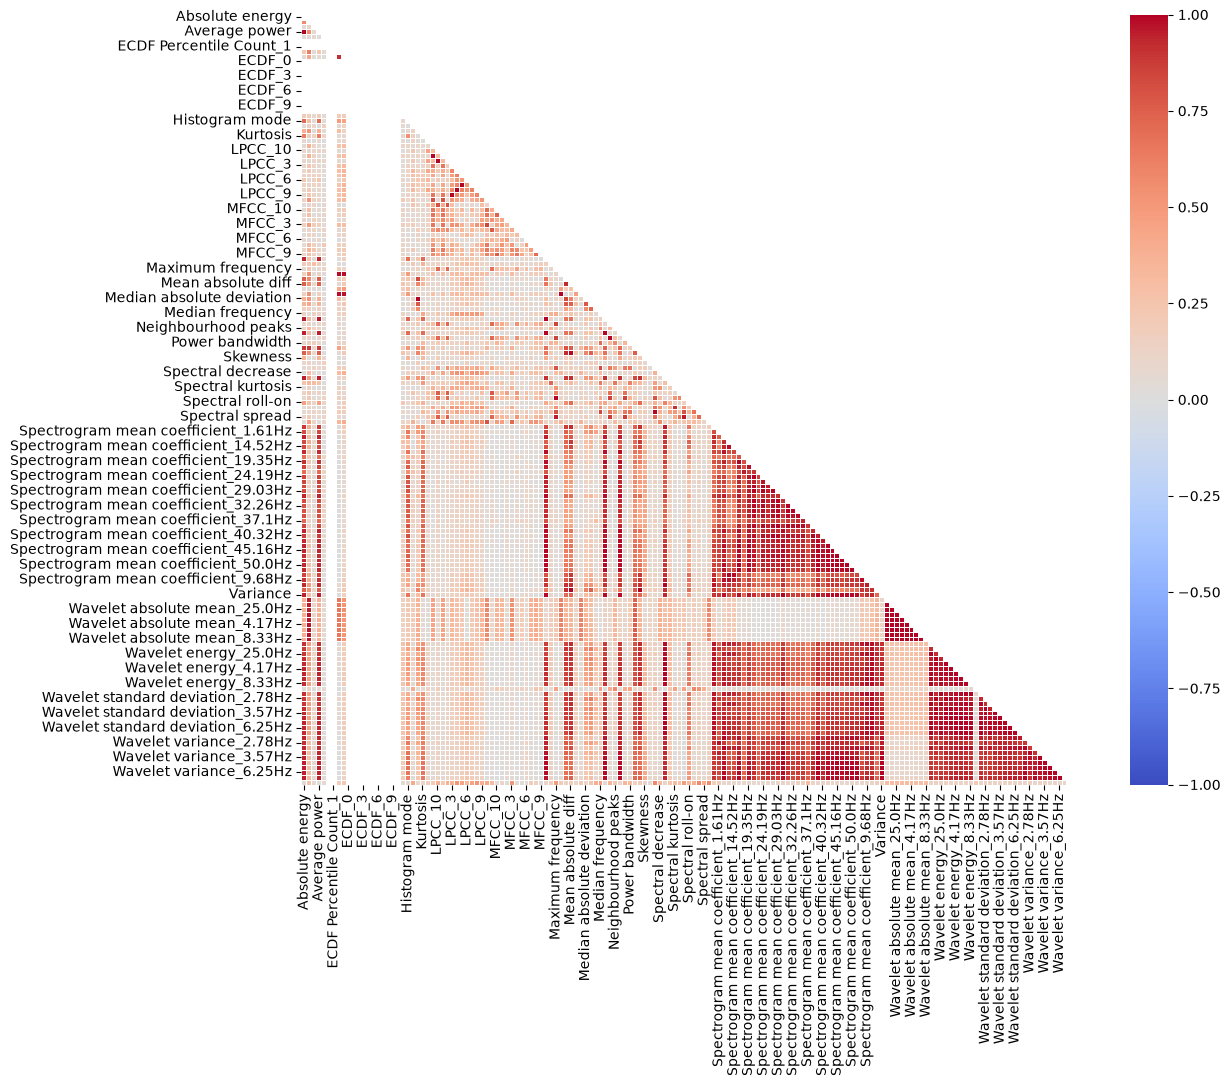

In [26]:
if os.path.exists(waveform_path):
    import seaborn as sns

    # Compute pairwise correlation of columns
    corr_matrix = new_X.drop('source_type', axis=1).corr().abs()

    # Mask the upper triangle (the matrix is symmetric)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    plt.figure(figsize=(15, 10))
    sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmax=1, vmin=-1,
                center=0, square=True, linewidths=.5, annot=False)
    plt.show()
else:
    print('Waveform file not found: skipping correlation heatmap.')

Des blocs de caractéristiques fortement corrélées sont redondants : ils portent la même information. La réduction de dimension (leçon suivante) ou la sélection de caractéristiques permet de les élaguer.

## Explorer l'espace des caractéristiques pour la classification

Nous traçons ici les distributions de caractéristiques choisies parmi les classes. Une caractéristique est utile à la classification quand ses distributions se séparent d'une classe à l'autre.

In [27]:
def plot_feature_histograms(new_X, feature):
    import seaborn as sns
    # Get unique source types
    source_types = new_X['source_type'].unique()

    # colorblind-friendly palette
    colors = sns.color_palette('colorblind')

    for i, source_type in enumerate(source_types):
        # Select data for this source type
        data = new_X[new_X['source_type'] == source_type][feature]

        # Plot histogram for this source type
        plt.hist(np.log10(data), color=colors[i % len(colors)], alpha=0.5,
                 label=source_type)

    plt.title(f'np.log10({feature})')
    plt.xlabel(f'np.log10({feature})')
    plt.ylabel('Count')
    plt.legend()
    plt.show()

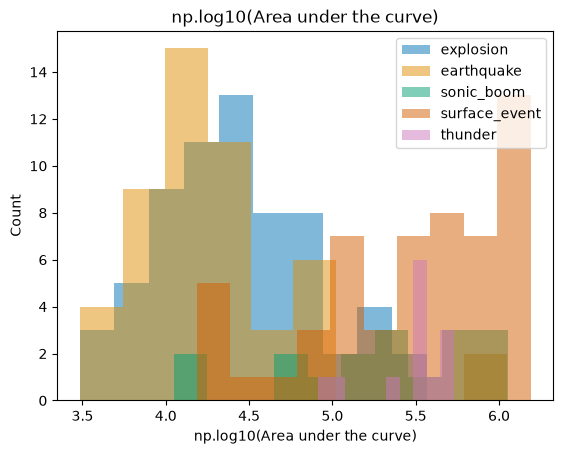

/Users/marinedenolle/Dropbox/CLASSES/ESS490/curriculum-book/.pixi/envs/default/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


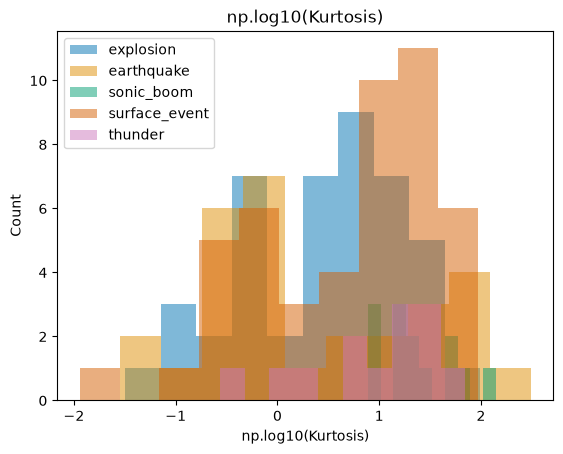

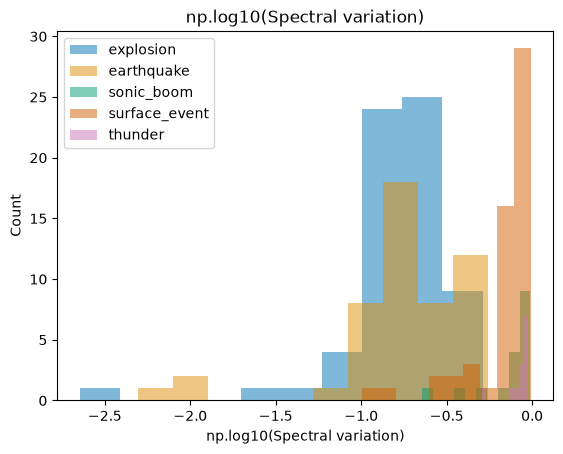

In [28]:
if os.path.exists(waveform_path):
    feature = 'Area under the curve'
    plot_feature_histograms(new_X, feature)

    feature = 'Kurtosis'
    plot_feature_histograms(new_X, feature)

    feature = 'Spectral variation'
    plot_feature_histograms(new_X, feature)
else:
    print('Waveform file not found: skipping feature histograms.')

### Exercice étudiant

```{admonition} 🤝 Assistant autorisé
:class: tip
Utilisez votre assistant si vous voulez — vérifiez chaque ligne et déclarez l'usage dans votre rendu ([1.8](../Chapter1-GettingStarted/1.8_ai_in_your_workflow.md)).
```

1. Laquelle de ces caractéristiques sera la meilleure pour classer les types d'événements ?

Appuyez-vous sur le canevas ci-dessous. L'idée : une caractéristique sépare bien deux classes quand l'écart entre les moyennes de classe est grand comparé à la dispersion à l'intérieur de chaque classe. Classez les caractéristiques selon ce critère.

In [29]:
if os.path.exists(waveform_path):
    # Answer scaffold: rank features by class separation.
    # Step 1: group the features by class.
    grouped = new_X.groupby('source_type')

    # Step 2: for each feature, compute the spread of the class means
    #         divided by the mean within-class standard deviation.
    feature_cols = new_X.columns.drop('source_type')
    class_means = grouped[feature_cols].mean()
    class_stds = grouped[feature_cols].std()
    separation = class_means.std(axis=0) / class_stds.mean(axis=0)

    # Step 3: sort and show the 10 most discriminative features.
    top10 = separation.sort_values(ascending=False).head(10)
    print(top10)

    # Step 4 (your turn): plot histograms of the top-ranked features with
    # plot_feature_histograms(new_X, feature) and check the separation by eye.
    # Step 5 (your turn): does the ranking change if you normalize each
    # feature first? Try (new_X - mean) / std before Step 2.
else:
    print('Waveform file not found: skipping student exercise scaffold.')

ECDF_9                     inf
ECDF_2                     inf
Entropy                    inf
ECDF_6                     inf
ECDF_5                     inf
ECDF_4                     inf
Spectral variation    2.033088
MFCC_0                1.909093
MFCC_3                1.392157
LPCC_11               1.376107
dtype: float64


```{admonition} Auto-vérification
:class: dropdown
- `separation` est une `Series` avec une valeur positive par colonne de caractéristique (156 ici) ; `class_means` et `class_stds` ont une ligne par classe (5) et une colonne par caractéristique.
- Certaines entrées valent `inf` : ces caractéristiques (plusieurs `ECDF_*`, `Entropy`) sont constantes à l'intérieur de chaque classe, donc l'écart-type intra-classe est nul. Écartez-les — une caractéristique constante ne porte aucune information par événement.
- Parmi les valeurs finies, les caractéristiques spectrales (`Spectral variation`, `MFCC_*`, `LPCC_*`) arrivent en tête, avec des séparations de l'ordre de 1 à 2.
- Étape 4 : les histogrammes des caractéristiques les mieux classées montrent des distributions de classes qui ne se recouvrent que partiellement ; une caractéristique mal classée donne des histogrammes presque identiques pour toutes les classes.
- Étape 5 : le classement ne change pas. Remettre une caractéristique à l'échelle multiplie par le même facteur la dispersion de ses moyennes de classe et sa dispersion intra-classe : leur rapport — et donc le classement — reste inchangé.
```